# Sampling distribution of the mean and CLT
## Sampling distribution of the mean

Imagine a huge population that consists of just three scores: 1, 2, and 3, and each one is equally likely to appear in a sample. (This is definitely NOT a normal distribution.)

Imagine that we can randomly select a sample of scores from this population.


In [23]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

population = [1, 2, 3]
sample_size = 15
num_samples = 10_000
sample_means_df = pd.DataFrame(columns=['index', 'sample', 'sample_mean'])

index_i = 0
for i in tqdm(range(num_samples)):
    sample = random.choices(population, k=sample_size)
    mean_of_the_sample = np.mean(sample)
    sample_means_df.loc[index_i] = [index_i, sample, mean_of_the_sample]
    index_i += 1

100%|██████████| 10000/10000 [00:02<00:00, 4532.58it/s]


In [25]:
sample_means_df.head()

,index,sample,sample_mean
0,0,"[3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 3, 1, 3, 3, 1]",2.33333
1,1,"[2, 3, 1, 3, 2, 2, 2, 2, 3, 2, 2, 1, 2, 2, 2]",2.06667
2,2,"[1, 2, 3, 3, 2, 1, 2, 1, 2, 2, 1, 3, 3, 2, 2]",2.00000
3,3,"[1, 1, 2, 2, 1, 3, 3, 3, 3, 2, 3, 3, 1, 3, 1]",2.13333
4,4,"[3, 3, 3, 3, 3, 2, 1, 2, 2, 3, 1, 3, 2, 3, 2]",2.40000


Text(0.5, 1.0, 'Distribution of Sample Means')

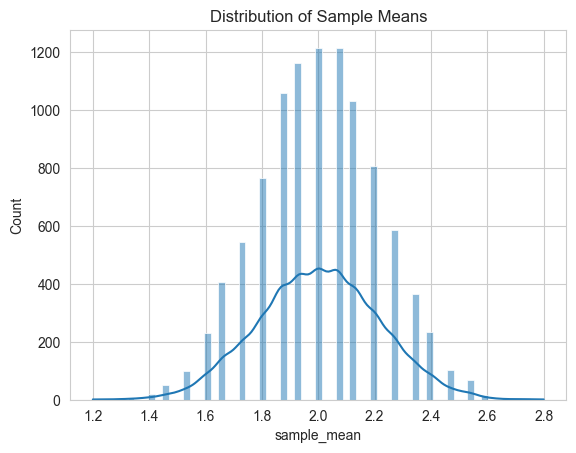

In [33]:
sns.histplot(data=sample_means_df, x='sample_mean', kde=True)
plt.title("Sampling distribution of the means")

## A simulation of the Central Limit Theorem (CLT)

We know the population has three possible values (1, 2, 3) and each one is equally likely to appear in a sample. Therefore, the population mean is likely to be $(1+2+3)/3=2$

Let's see what happens if the sample size is large enough.

The larger it is, the more likely and more closely the mean value falls around 2.

In [43]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

population = [1, 2, 3]
large_sample_size = 100
large_sample = random.choices(population, k=large_sample_size)
print(f"The large sample of {len(large_sample)} mean is {np.mean(large_sample):.2f}")


The large sample of 100 mean is 2.08


## Example: COVID data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df=pd.read_csv("../05-data_cleaning/data/covidtotals.csv")

df.head()

,iso_code,lastdate,location,total_cases,total_deaths,total_cases_pm,total_deaths_pm,population,pop_density,median_age,gdp_per_capita,hosp_beds,vac_per_hund,aged_65_older,life_expectancy,hum_dev_ind,region
0,AFG,2024-02-04,Afghanistan,231539.0,7982.0,5629.611,194.073,41128772,54.422,18.6,1803.987,0.50,NaN,2.581,64.83,0.511,South Asia
1,ALB,2024-01-28,Albania,334863.0,3605.0,117813.348,1268.331,2842318,104.871,38.0,11803.431,2.89,NaN,13.188,78.57,0.795,Eastern Europe
2,DZA,2023-12-03,Algeria,272010.0,6881.0,6057.694,153.241,44903228,17.348,29.1,13913.839,1.90,NaN,6.211,76.88,0.748,North Africa
3,ASM,2023-09-17,American Samoa,8359.0,34.0,188712.044,767.581,44295,278.205,NaN,NaN,NaN,NaN,NaN,73.74,NaN,Oceania / Aus
4,AND,2023-05-07,Andorra,48015.0,159.0,601367.684,1991.408,79843,163.755,NaN,NaN,NaN,NaN,NaN,83.73,0.868,Western Europe


In [4]:
df['total_cases'].mean()

np.float64(3351598.5844155843)

<Axes: xlabel='total_cases', ylabel='Count'>

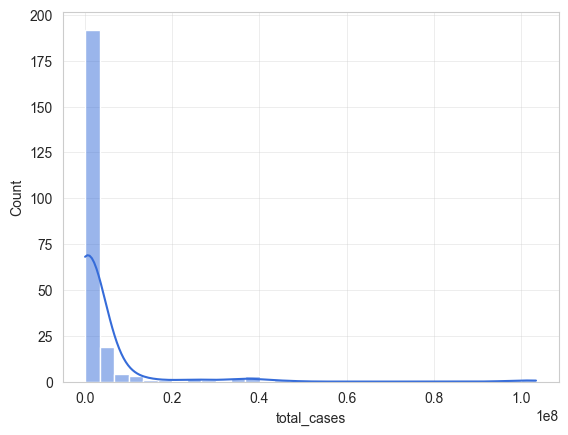

In [7]:
sns.set_style("whitegrid")
sns.histplot(data=df, x='total_cases', kde=True)

### Simulate CLT

In [31]:
from tqdm import tqdm
sample_size = 10
num_sample = 100

sample_means = []

for i in tqdm(range(num_sample)):
    sample = df.sample(n=sample_size)['total_cases'].to_list()
    sample_means.append(np.mean(sample))

print(np.mean(sample_means))


100%|██████████| 100/100 [00:00<00:00, 14678.23it/s]

3385770.246


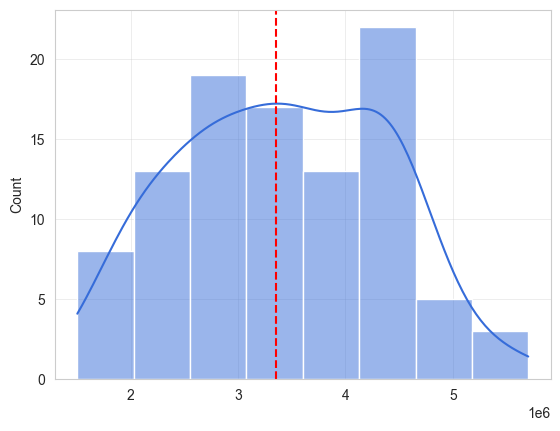

In [39]:
sns.set_style("whitegrid")
sns.histplot(data=sample_means, kde=True)
plt.axvline(x=df['total_cases'].mean(), color='red', linestyle='dashed')

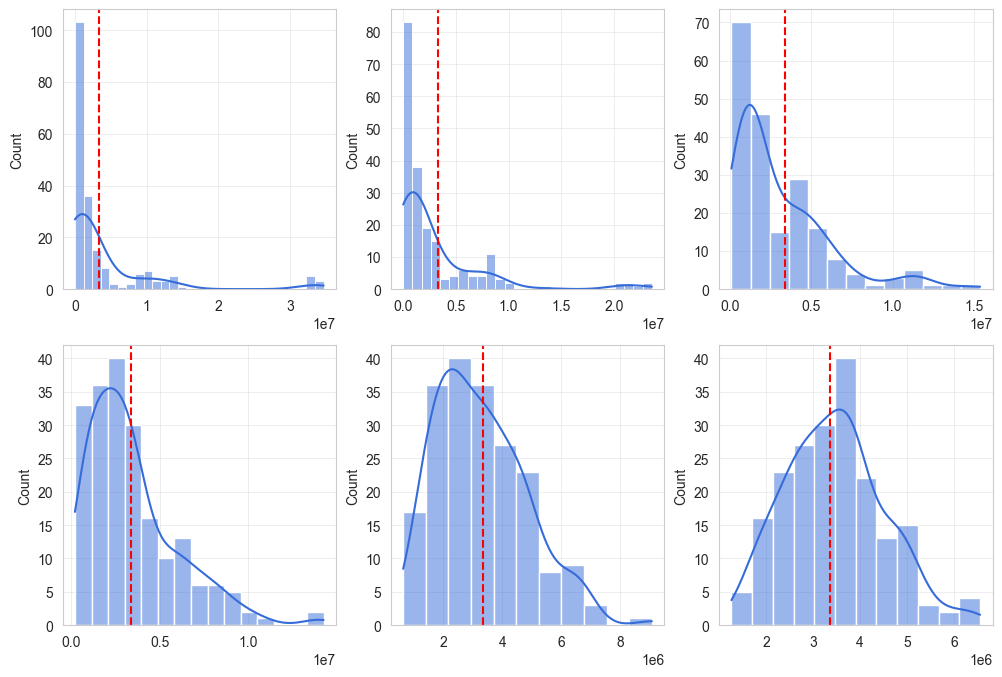

In [47]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
num_sample=200
for size_, ax in zip([3, 5, 10, 20, 50, 80], axes.flat):
    sample_means = []

    for i in range(num_sample):
        sample = df.sample(n=size_)['total_cases'].to_list()
        sample_means.append(np.mean(sample))

    g0=sns.histplot(data=sample_means, kde=True, ax=ax)
    ax.axvline(x=df['total_cases'].mean(), color='red', linestyle='dashed')
